# MediaPipe FaceMesh - ejemplo básico

Este notebook carga una imagen de muestra, detecta landmarks faciales con FaceMesh y los dibuja sobre la imagen.

La imagen de ejemplo está en `./data/sample_face.jpg`.

In [8]:
# Uninstall conflicting tensorflow to resolve protobuf issues with mediapipe
!pip uninstall -y tensorflow tensorflow-estimator keras

# Install mediapipe and compatible libraries
!pip install mediapipe==0.10.14 opencv-python==4.10.0.84 "numpy<2" matplotlib

REINICIAR SESION antes de continuar


**IMPORTANT:** Please restart the Colab runtime now (Runtime -> Restart runtime) for the dependency changes to take full effect before proceeding with the `setup` cell and other code.

In [1]:

#BAJAR Y CARGAR EJEMPLO DE IMAGEN DE ROSTRO

import requests

image_url = "https://www.freeiconspng.com/uploads/face-png-2.png"
image_filename = "sample_face.jpg"

response = requests.get(image_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

with open(image_filename, 'wb') as f:
    f.write(response.content)

print(f"Downloaded {image_filename}")

Downloaded sample_face.jpg


In [2]:
%matplotlib inline

from pathlib import Path

In [3]:
IMG_PATH = Path("sample_face.jpg")

In [4]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

# Helper functions for image display and loading
def show_bgr(image_bgr, title=None):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def load_image(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró {path}. El notebook probablemente se ejecutó desde otra carpeta."
        )
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"No se pudo leer la imagen: {path}")
    return image

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


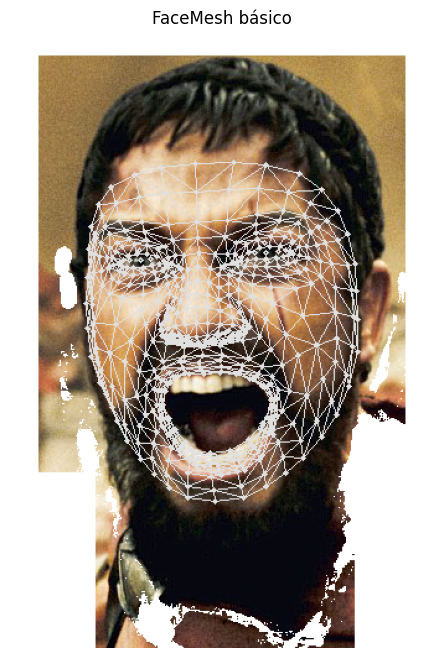

Landmarks detectados: 478
Primeros 5 puntos:
[[152 267]
 [150 246]
 [154 254]
 [143 212]
 [150 235]]


In [5]:
image_bgr = load_image(IMG_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
height, width, _ = image_bgr.shape

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:
    results = face_mesh.process(image_rgb)

if not results.multi_face_landmarks:
    print("No se detectó ningún rostro. Probá con otra imagen.")
else:
    annotated = image_bgr.copy()
    for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            image=annotated,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=drawing_spec,
            connection_drawing_spec=drawing_spec,
        )

    show_bgr(annotated, title="FaceMesh básico")

    keypoints = np.array([
        (int(lm.x * width), int(lm.y * height))
        for lm in results.multi_face_landmarks[0].landmark
    ])
    print(f"Landmarks detectados: {len(keypoints)}")
    print("Primeros 5 puntos:")
    print(keypoints[:5])
